# Dataset Exploration — Screw Category (MVTec-AD)

This notebook explores the `screw` category manifest (`data/manifests/screw.csv`) generated by
[`src/data/create_manifest.py`](../src/data/create_manifest.py).

| Check | Purpose |
|---|---|
| Number of train good images | Confirm training data size |
| Number of test good images | Confirm normal test data |
| Number of defective images by type | Understand class distribution |
| Example original image + mask | Verify mask matching |
| Image dimensions | Decide resize size |


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

PROJECT_ROOT = Path.cwd().parent
MANIFEST_PATH = PROJECT_ROOT / "data" / "manifests" / "screw.csv"

df = pd.read_csv(MANIFEST_PATH)
df.head()

,image_path,mask_path,split,label,defect_type
0,data/mvtec_anomaly_detection/screw/train/good/...,NaN,train,0,good
1,data/mvtec_anomaly_detection/screw/train/good/...,NaN,train,0,good
2,data/mvtec_anomaly_detection/screw/train/good/...,NaN,train,0,good
3,data/mvtec_anomaly_detection/screw/train/good/...,NaN,train,0,good
4,data/mvtec_anomaly_detection/screw/train/good/...,NaN,train,0,good


## Number of train good images

In [2]:
n_train_good = len(df[(df["split"] == "train") & (df["label"] == 0)])
print(f"Train good images: {n_train_good}")

Train good images: 320


## Number of test good images

In [3]:
n_test_good = len(df[(df["split"] == "test") & (df["label"] == 0)])
print(f"Test good images: {n_test_good}")

Test good images: 41


## Number of defective images by type

defect_type
manipulated_front    24
scratch_head         24
scratch_neck         25
thread_side          23
thread_top           23
Name: count, dtype: int64


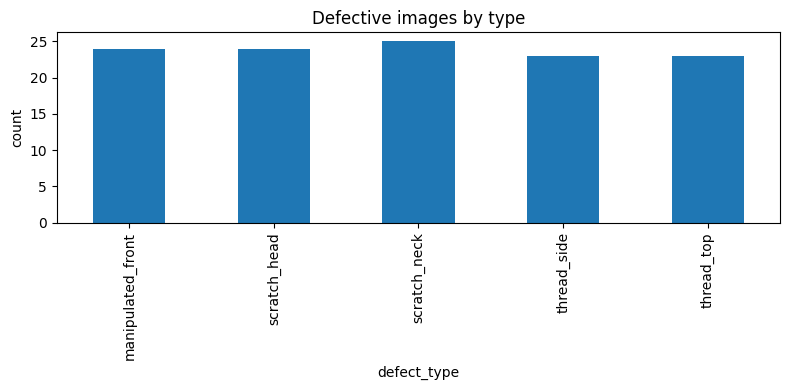

In [4]:
defect_counts = (
    df[df["label"] == 1]["defect_type"].value_counts().sort_index()
)
print(defect_counts)

defect_counts.plot(kind="bar", figsize=(8, 4), title="Defective images by type")
plt.ylabel("count")
plt.xlabel("defect_type")
plt.tight_layout()
plt.show()

## Image dimensions

Sample a handful of images from each split to check whether all images share the same
resolution (useful for deciding a resize size for the model pipeline).

In [5]:
sample_paths = pd.concat(
    [
        df[(df["split"] == "train") & (df["label"] == 0)].sample(
            min(5, n_train_good), random_state=0
        ),
        df[(df["split"] == "test") & (df["label"] == 0)].sample(
            min(5, n_test_good), random_state=0
        ),
        df[df["label"] == 1].sample(min(5, (df["label"] == 1).sum()), random_state=0),
    ]
)["image_path"]

dims = []
for rel_path in sample_paths:
    with Image.open(PROJECT_ROOT / rel_path) as img:
        dims.append({"image_path": rel_path, "width": img.width, "height": img.height, "mode": img.mode})

dims_df = pd.DataFrame(dims)
dims_df

,image_path,width,height,mode
0,data/mvtec_anomaly_detection/screw/train/good/...,1024,1024,L
1,data/mvtec_anomaly_detection/screw/train/good/...,1024,1024,L
2,data/mvtec_anomaly_detection/screw/train/good/...,1024,1024,L
3,data/mvtec_anomaly_detection/screw/train/good/...,1024,1024,L
4,data/mvtec_anomaly_detection/screw/train/good/...,1024,1024,L
5,data/mvtec_anomaly_detection/screw/test/good/0...,1024,1024,L
6,data/mvtec_anomaly_detection/screw/test/good/0...,1024,1024,L
7,data/mvtec_anomaly_detection/screw/test/good/0...,1024,1024,L
8,data/mvtec_anomaly_detection/screw/test/good/0...,1024,1024,L
9,data/mvtec_anomaly_detection/screw/test/good/0...,1024,1024,L


## Visualize: original image, ground-truth mask, and overlay

Pick one defective example and display the original screw image next to its
ground-truth mask and an overlay of the two (mask in red).

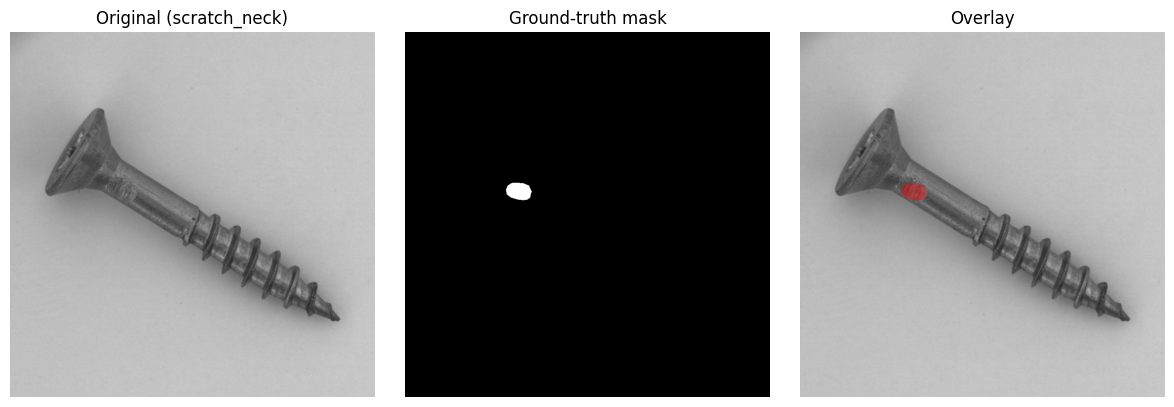

In [6]:
defective = df[df["label"] == 1].dropna(subset=["mask_path"])
defective = defective[defective["mask_path"] != ""]
example = defective.sample(1, random_state=0).iloc[0]

image = Image.open(PROJECT_ROOT / example["image_path"]).convert("RGB")
mask = Image.open(PROJECT_ROOT / example["mask_path"]).convert("L")

image_np = np.array(image)
mask_np = np.array(mask)

overlay = image_np.copy()
overlay[mask_np > 0] = [255, 0, 0]
overlay = (0.6 * image_np + 0.4 * overlay).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image_np)
axes[0].set_title(f"Original ({example['defect_type']})")
axes[1].imshow(mask_np, cmap="gray")
axes[1].set_title("Ground-truth mask")
axes[2].imshow(overlay)
axes[2].set_title("Overlay")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()